# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

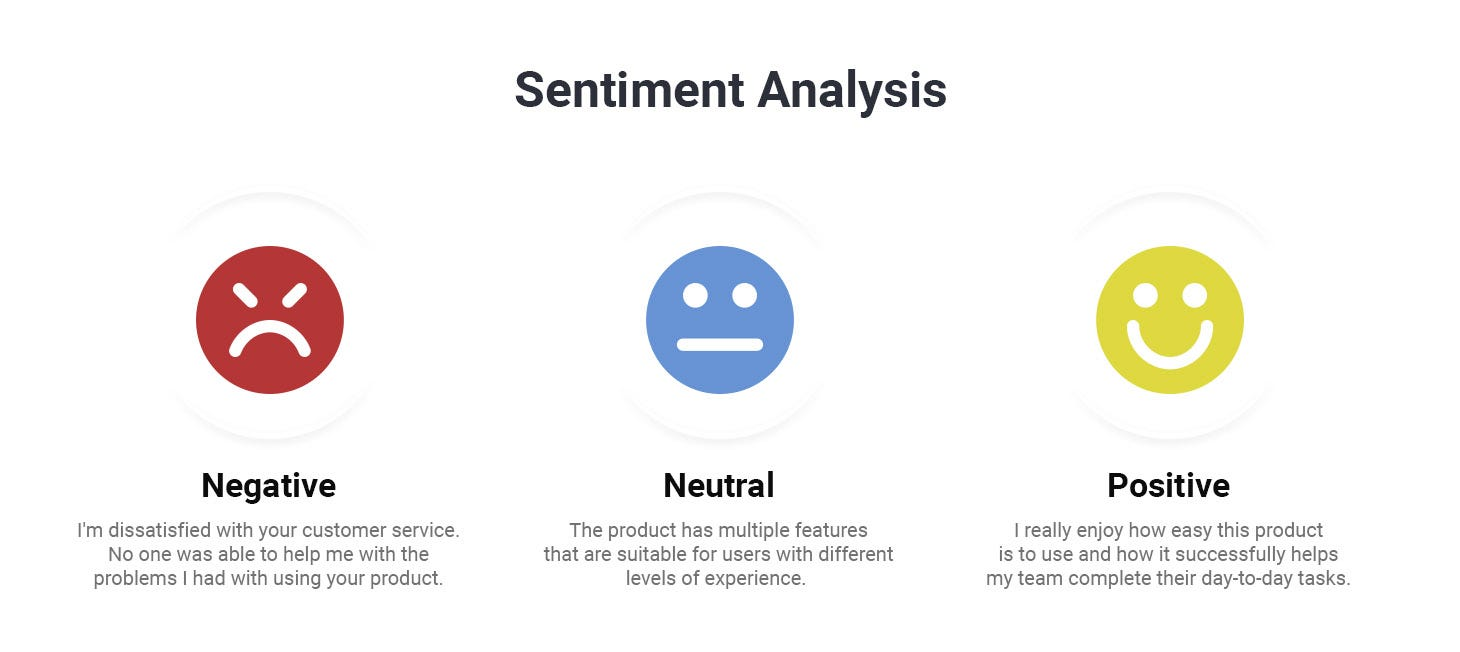

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [ ]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

## Task 1: Load the data and do 5 different preprocessing steps

In [1]:
%matplotlib inline
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from functools import lru_cache
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

CSV_PATH = 'Amazon_Unlocked_Mobile.csv'
if not os.path.exists(CSV_PATH):
    CSV_PATH = '/content/Amazon_Unlocked_Mobile.csv'

data = pd.read_csv(CSV_PATH)
print(data.shape)
data.head()

(413840, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [2]:
# Missing values
data.isna().sum()

Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

In [3]:
# Keep the needed columns, drop missing reviews/ratings and duplicated reviews
data = data[['Reviews', 'Rating']].dropna()
data = data.drop_duplicates(subset=['Reviews'])

# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(
    lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral')
)

print(data.shape)
data['Sentiment'].value_counts()

(162490, 3)


Sentiment
positive    103773
negative     44351
neutral      14366
Name: count, dtype: int64

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


@lru_cache(maxsize=200000)
def lemmatize(word):
    return lemmatizer.lemmatize(word)


def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation, digits and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 3. Tokenize the text
    words = text.split()

    # 4. Remove stopwords and very short tokens
    words = [w for w in words if w not in stop_words and len(w) > 2]

    # 5. Lemmatization
    words = [lemmatize(w) for w in words]

    return ' '.join(words)


# Apply preprocessing to the review text
data['Clean_Review'] = data['Reviews'].astype(str).apply(preprocess_text)

# Drop reviews that became empty after cleaning
data = data[data['Clean_Review'].str.strip() != '']

data[['Reviews', 'Clean_Review', 'Sentiment']].head()

,Reviews,Clean_Review,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky found used phone used hard phone li...,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,positive
2,Very pleased,pleased,positive
3,It works good but it goes slow sometimes but i...,work good go slow sometimes good phone love,positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,positive


## Task 2: Use a proper train and test split

In [5]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    data['Clean_Review'],
    data['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=data['Sentiment']
)

print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (129712,)
test_data size: (32428,)


## Task 3: Feature Extraction Using TF-IDF

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

print(train_vectors.shape)
print(test_vectors.shape)

(129712, 5000)
(32428, 5000)


## Task 4: Train a Naive Bayes Classifier

In [7]:
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()
nb_classifier.fit(train_vectors, train_labels)

predictions = nb_classifier.predict(test_vectors)

## Task 5: Evaluate the model on the Test Set

In [8]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

print("Classification Report:")
print(classification_report(test_labels, predictions))

Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.72      0.76      8859
     neutral       0.29      0.02      0.03      2864
    positive       0.82      0.96      0.89     20705

    accuracy                           0.81     32428
   macro avg       0.64      0.57      0.56     32428
weighted avg       0.77      0.81      0.77     32428



## Task 6: Confusion Matrix

Confusion Matrix:
                 predicted_negative  predicted_neutral  predicted_positive
actual_negative                6353                 53                2453
actual_neutral                  868                 53                1943
actual_positive                 706                 75               19924


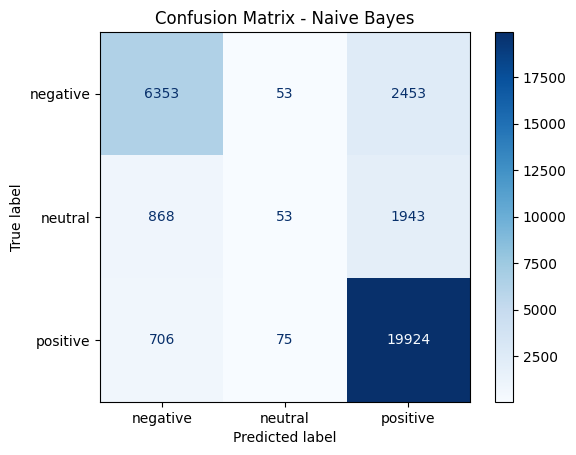

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(test_labels, predictions, labels=labels)

print("Confusion Matrix:")
print(pd.DataFrame(cm,
                   index=[f'actual_{l}' for l in labels],
                   columns=[f'predicted_{l}' for l in labels]))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap='Blues', values_format='d'
)
plt.title('Confusion Matrix - Naive Bayes')
plt.show()